# Import Important/Required Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Import Dataset

In [2]:
import os
os.getcwd()

'c:\\Users\\admin\\Desktop\\jupyternotebook'

In [3]:
os.chdir(r"C:\Users\admin\Documents")  # Change to the correct directory

In [4]:
df=pd.read_csv("Student_performance.csv")

# Check Size of Dataset

In [5]:
df.shape

(666, 12)

In [6]:
df.head()

,Gender,Caste,coaching,Class_ten_education,twelve_education,medium,Class_X_Percentage,Class_XII_Percentage,Father_occupation,Mother_occupation,time,Performance
0,male,General,NO,SEBA,AHSEC,ENGLISH,Excellent,Excellent,DOCTOR,OTHERS,ONE,Excellent
1,male,OBC,WA,SEBA,AHSEC,OTHERS,Excellent,Excellent,SCHOOL_TEACHER,HOUSE_WIFE,TWO,Excellent
2,male,OBC,OA,OTHERS,CBSE,ENGLISH,Excellent,Excellent,BUSINESS,HOUSE_WIFE,TWO,Excellent
3,male,General,WA,SEBA,AHSEC,OTHERS,Excellent,Excellent,SCHOOL_TEACHER,SCHOOL_TEACHER,ONE,Excellent
4,male,General,OA,SEBA,CBSE,ENGLISH,Excellent,Excellent,COLLEGE_TEACHER,HOUSE_WIFE,TWO,Excellent


# Check NULL Values are Present Or Not

In [7]:
df.isnull().sum()

Gender                  0
Caste                   0
coaching                0
Class_ten_education     0
twelve_education        0
medium                  0
Class_X_Percentage      0
Class_XII_Percentage    0
Father_occupation       0
Mother_occupation       0
time                    0
Performance             0
dtype: int64

->There are no null values

# Check Basic Information about a DataFrame

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 666 entries, 0 to 665
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Gender                666 non-null    object
 1   Caste                 666 non-null    object
 2   coaching              666 non-null    object
 3   Class_ten_education   666 non-null    object
 4   twelve_education      666 non-null    object
 5   medium                666 non-null    object
 6   Class_X_Percentage    666 non-null    object
 7   Class_XII_Percentage  666 non-null    object
 8   Father_occupation     666 non-null    object
 9   Mother_occupation     666 non-null    object
 10  time                  666 non-null    object
 11  Performance           666 non-null    object
dtypes: object(12)
memory usage: 62.6+ KB


-> The dataset contains only categorical variables, and all entries are complete with no missing values.

# Summary Statistics for Categorical Dataset

In [9]:
df.describe()

,Gender,Caste,coaching,Class_ten_education,twelve_education,medium,Class_X_Percentage,Class_XII_Percentage,Father_occupation,Mother_occupation,time,Performance
count,666,666,666,666,666,666,666,666,666,666,666,666
unique,2,4,3,3,3,3,4,4,8,9,6,4
top,male,General,WA,SEBA,AHSEC,ENGLISH,Excellent,Excellent,OTHERS,HOUSE_WIFE,TWO,Good
freq,355,329,449,396,368,536,511,398,277,442,368,210


# Identify Duplicate Values

In [10]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
661    False
662    False
663    False
664     True
665    False
Length: 666, dtype: bool

# Drop Duplicate Values

In [11]:
df=df.drop_duplicates(keep="first")
print(df)

     Gender    Caste coaching Class_ten_education twelve_education   medium  \
0      male  General       NO                SEBA            AHSEC  ENGLISH   
1      male      OBC       WA                SEBA            AHSEC   OTHERS   
2      male      OBC       OA              OTHERS             CBSE  ENGLISH   
3      male  General       WA                SEBA            AHSEC   OTHERS   
4      male  General       OA                SEBA             CBSE  ENGLISH   
..      ...      ...      ...                 ...              ...      ...   
660  female       ST       WA                SEBA             CBSE  ENGLISH   
661  female       ST       WA                SEBA            AHSEC  ENGLISH   
662    male       ST       WA                SEBA            AHSEC  ENGLISH   
663    male       ST       WA                SEBA             CBSE  ENGLISH   
665  female       ST       NO                SEBA             CBSE  ENGLISH   

    Class_X_Percentage Class_XII_Percentage Father_

In [12]:
df.shape

(622, 12)

# Visual Analysis of Categorical Features vs Performance

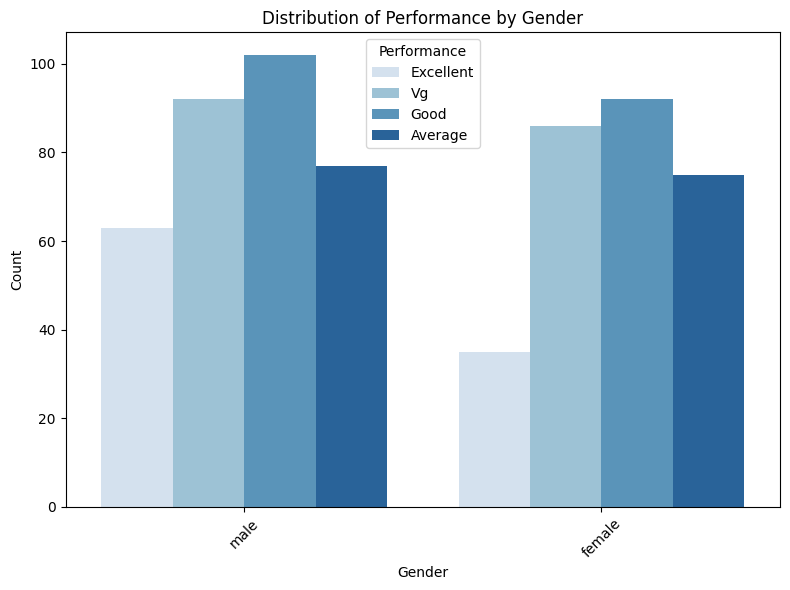

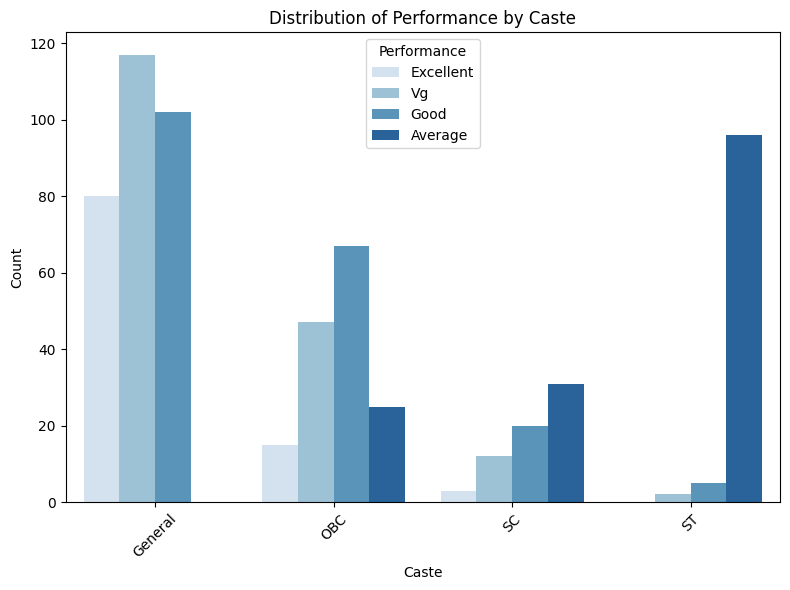

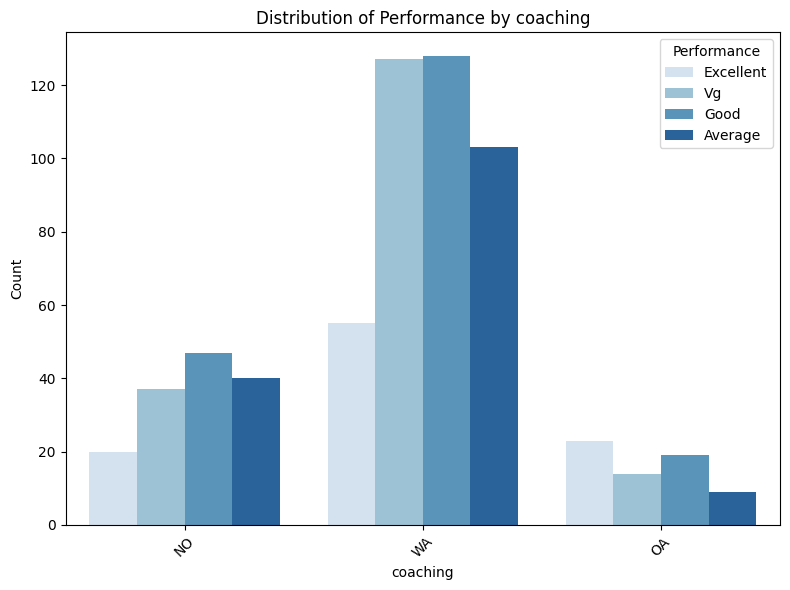

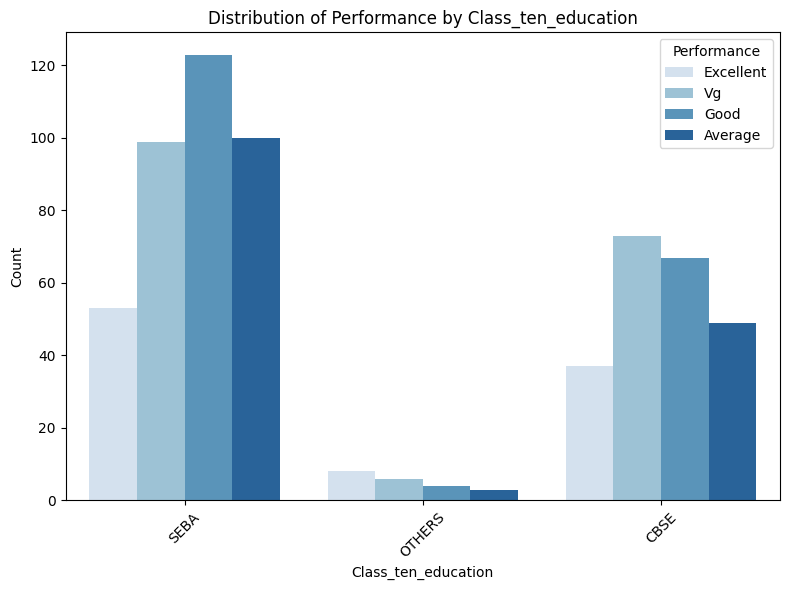

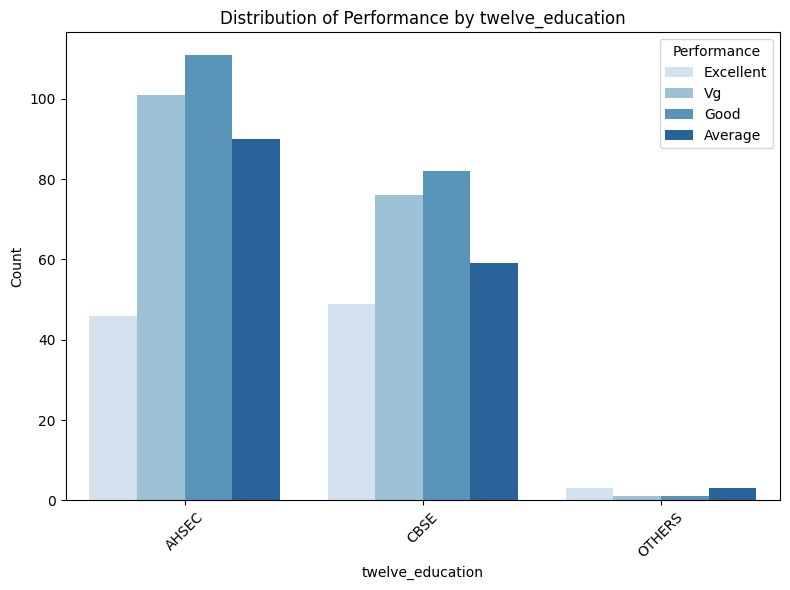

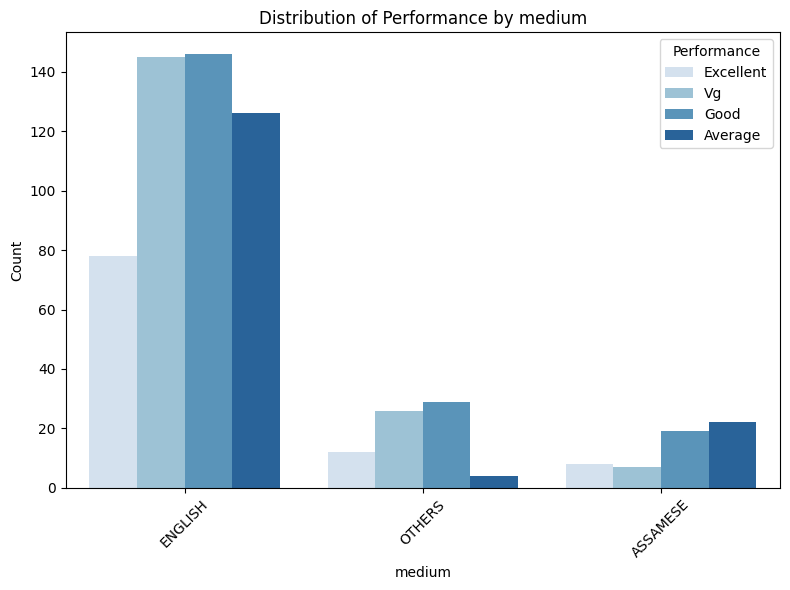

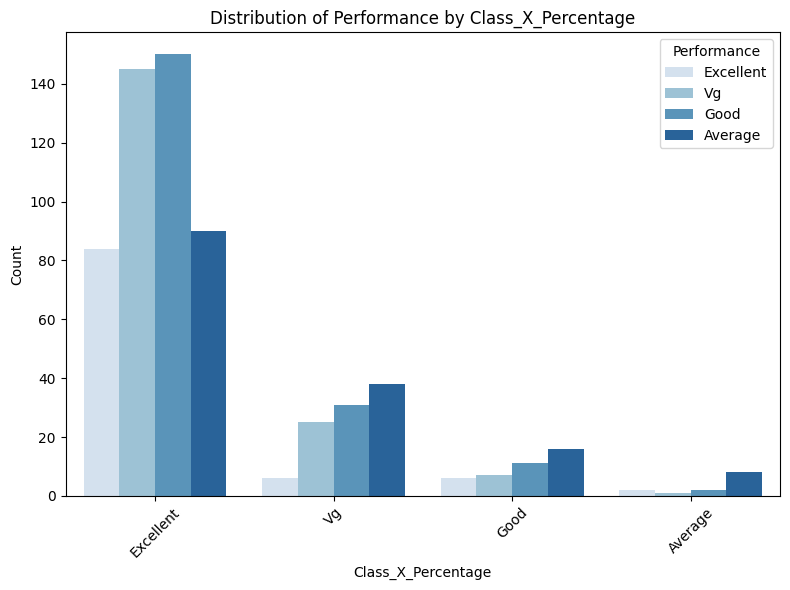

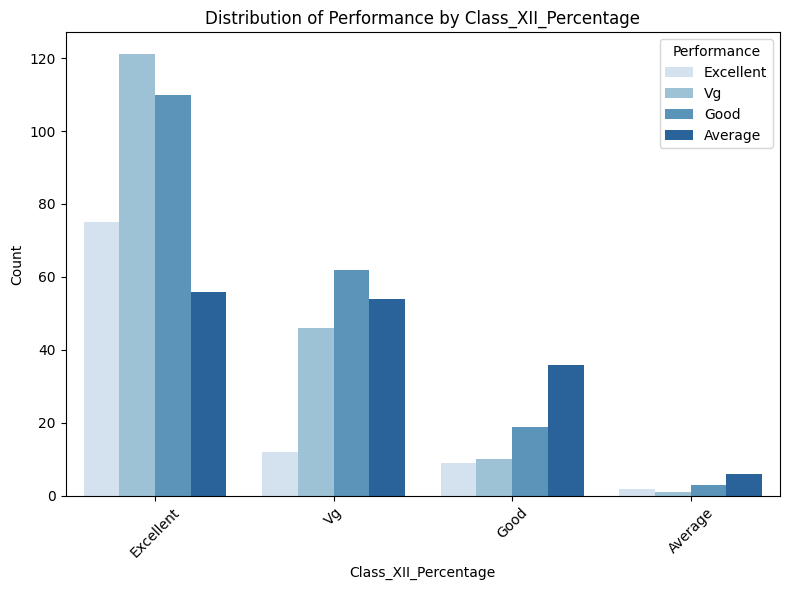

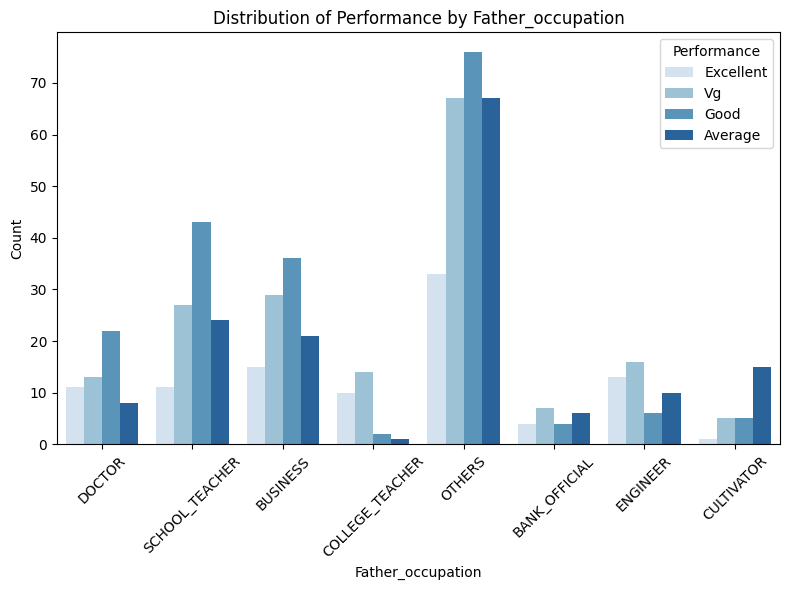

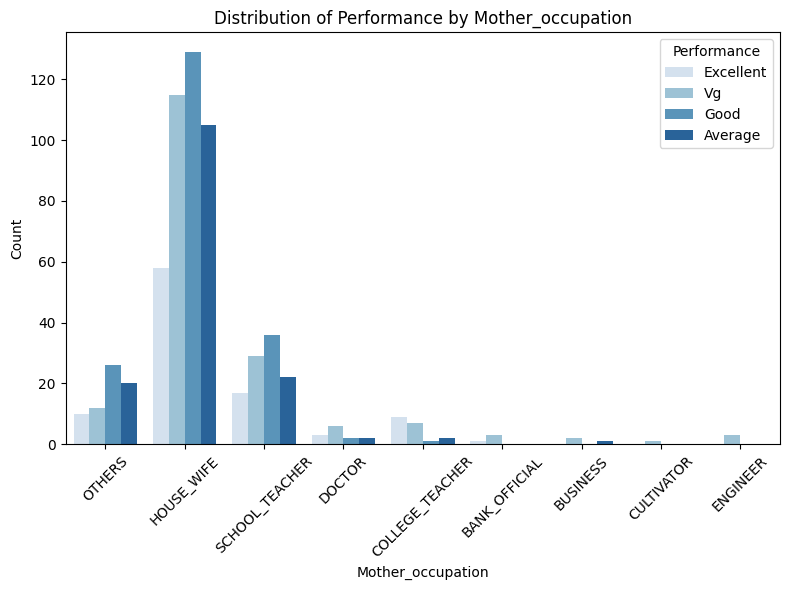

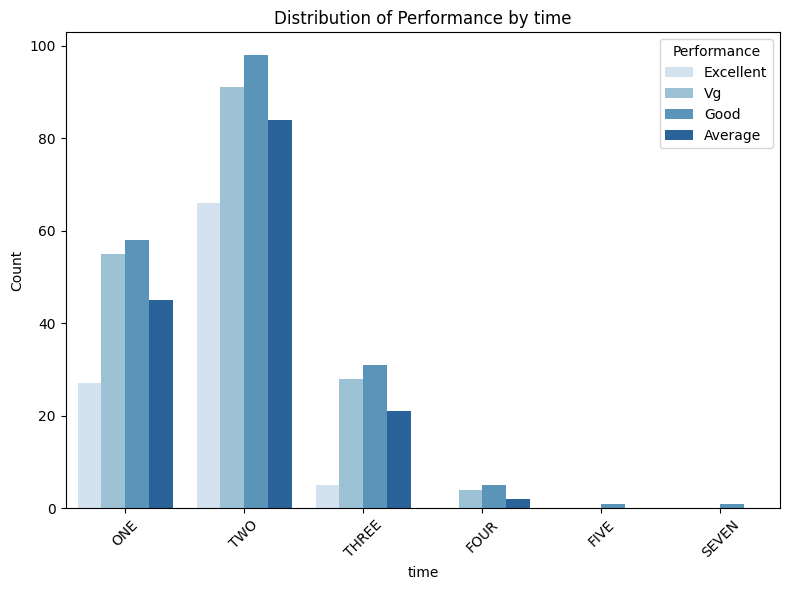

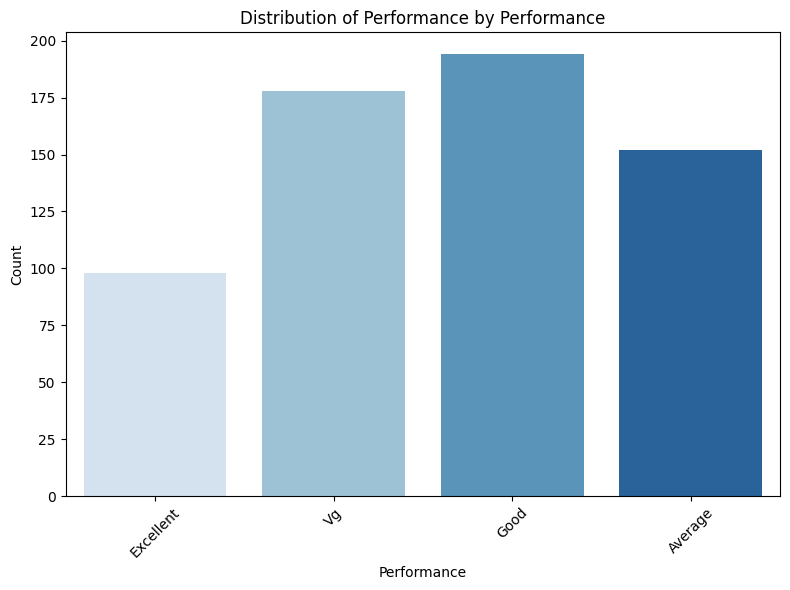

In [13]:
columns=['Gender', 'Caste', 'coaching', 'Class_ten_education',
       'twelve_education', 'medium', 'Class_X_Percentage',
       'Class_XII_Percentage', 'Father_occupation', 'Mother_occupation',
       'time', 'Performance']
for col in columns:

    plt.figure(figsize=(8,6))
    sns.countplot(x=col, hue='Performance', data=df,palette="Blues")
    plt.title(f'Distribution of Performance by {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()
    
    


The above graphs illustrate the relationship between performance based on various factors such as gender, caste, education type, and parents' jobs.

  -> Groups excel in a particular set of features more than others.

  -> Performance may be influenced by gender and education background.

  -> Some categories have more students and that can affect the results too.

  ->Parents’ professions also appear to have some impact on students’ performance.

# Convert Categorical Columns to Numerical using Label Encoding

In [14]:
from sklearn.preprocessing import LabelEncoder

columns_encode=['Gender', 'Caste', 'coaching', 'Class_ten_education',
       'twelve_education', 'medium', 'Class_X_Percentage',
       'Class_XII_Percentage', 'Father_occupation', 'Mother_occupation',
       'time', 'Performance']

le=LabelEncoder()
for col in columns_encode:
    df[col]=le.fit_transform(df[col])

df.head()

,Gender,Caste,coaching,Class_ten_education,twelve_education,medium,Class_X_Percentage,Class_XII_Percentage,Father_occupation,Mother_occupation,time,Performance
0,1,0,0,2,0,1,1,1,4,7,2,1
1,1,1,2,2,0,2,1,1,7,6,5,1
2,1,1,1,1,1,1,1,1,1,6,5,1
3,1,0,2,2,0,2,1,1,7,8,2,1
4,1,0,1,2,1,1,1,1,2,6,5,1


# Calculate The Correlation Matrix

In [15]:
correlation_matrix=df.corr()
print(correlation_matrix)

                        Gender     Caste  coaching  Class_ten_education  \
Gender                1.000000 -0.073622 -0.112801            -0.044000   
Caste                -0.073622  1.000000 -0.014235             0.053556   
coaching             -0.112801 -0.014235  1.000000             0.085274   
Class_ten_education  -0.044000  0.053556  0.085274             1.000000   
twelve_education      0.015858 -0.043374 -0.061932            -0.759510   
medium                0.113940 -0.128726 -0.031694             0.046370   
Class_X_Percentage    0.088215  0.119155  0.063951             0.191549   
Class_XII_Percentage  0.034975  0.147274  0.153061             0.099998   
Father_occupation     0.072796  0.049218  0.047914             0.024292   
Mother_occupation     0.064027  0.045106  0.015052             0.052189   
time                 -0.023217 -0.005205  0.344017             0.011631   
Performance          -0.013383 -0.607660  0.043488            -0.056895   

                      tw

# Visualize the Correlation Matrix using a Heatmap


<Axes: >

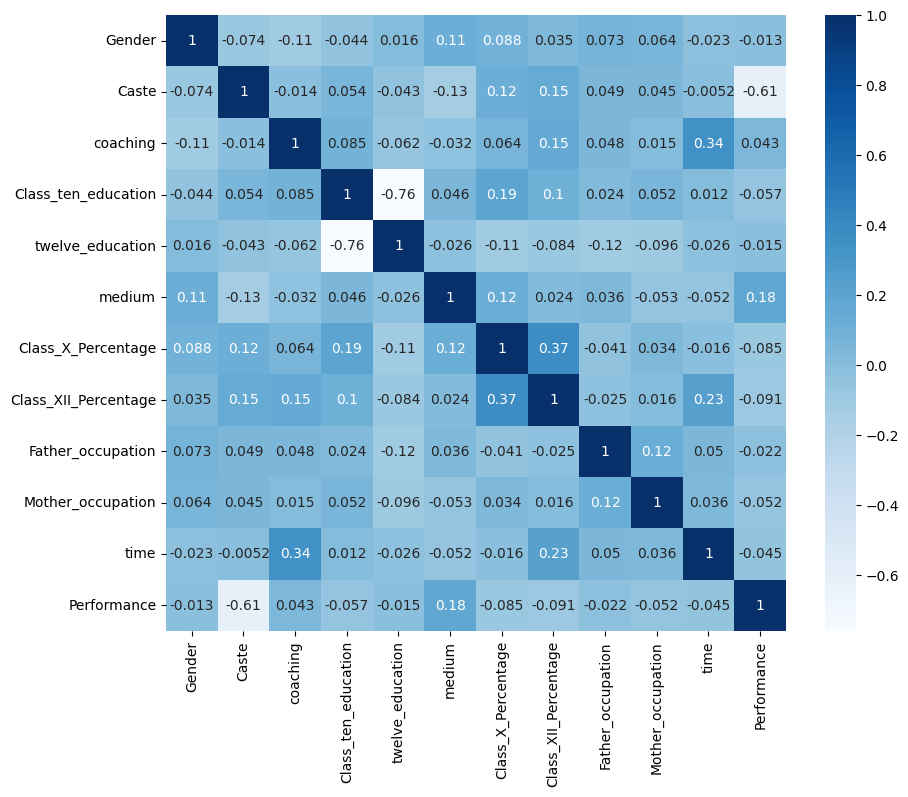

In [19]:
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix,cmap="Blues",annot=True)